# Reinforcement Learning Foundations

In Dynamic Programming, we assumed that the environment model was known.

Given the transition model

$$
T(x'|x,u),
$$

we could compute expectations over possible next states and solve the
decision-making problem using methods such as Policy Iteration and Value
Iteration.

In many real systems, however, the transition model is unknown.

Instead of being given

$$
T(x'|x,u),
$$

the agent interacts with the environment and observes transitions:

$$
(x_t,u_t,r_{t+1},x_{t+1}).
$$

The central question of this notebook is:

> How can we estimate value functions and improve policies using sampled
> experience instead of a known dynamics model?

We will develop the progression:

$$
\boxed{
\text{Dynamic Programming}
\rightarrow
\text{Monte Carlo}
\rightarrow
\text{Temporal Difference Learning}
}
$$

These ideas form the foundation for later algorithms such as SARSA,
Q-learning, DQN, Actor-Critic, and PPO.

## 1. Where Dynamic Programming Stops

Consider the Bellman expectation equation for a fixed policy:

$$
V^\pi(x)=
\sum_u
\pi(u|x)
\sum_{x'}
T(x'|x,u)
\left[
R(x,u,x')
+
\gamma V^\pi(x')
\right].
$$

The important operation here is the expectation over possible next states:

$$
\sum_{x'}
T(x'|x,u)(\cdots).
$$

To compute this exactly, we need to know the transition probabilities:

$$
T(x'|x,u).
$$

This was possible in our Dynamic Programming setting because the MDP model
was assumed to be known.

But suppose we interact with a system whose transition model is unknown.

We take an action:

$$
u_t
$$

and observe only one transition:

$$
x_t
\rightarrow
u_t
\rightarrow
r_{t+1}
\rightarrow
x_{t+1}.
$$

We no longer have the complete probability distribution

$$
T(x'|x,u).
$$

We only have samples generated by the environment.

This changes the problem from:

$$
\boxed{\text{Compute expectations from a known model}}
$$

to:

$$
\boxed{\text{Estimate expectations from experience}}
$$

## 2. A Small Environment for Learning

To understand learning from experience, we use a small one-dimensional
environment.

The state space is:

$$
\mathcal X=
\{0,1,2,3,4,5\}.
$$

States 0 and 5 are terminal states.

The available actions are:

$$
\mathcal U=
\{\text{LEFT},\text{RIGHT}\}.
$$

The agent starts in one of the non-terminal states.

The reward is:

$$
r_{t+1}=
\begin{cases}
1, & x_{t+1}=5 \\
0, & \text{otherwise}.
\end{cases}
$$

The purpose of this environment is not to solve a difficult control problem.

Instead, it allows us to directly observe how estimates of

$$
V^\pi(x)
$$

change as the agent collects experience.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N_STATES = 6

LEFT = 0
RIGHT = 1

TERMINAL_LEFT = 0
TERMINAL_RIGHT = 5


def environment_step(state, action):

    if action == LEFT:
        next_state = state - 1

    else:
        next_state = state + 1

    reward = 1.0 if next_state == TERMINAL_RIGHT else 0.0

    done = (
        next_state == TERMINAL_LEFT
        or next_state == TERMINAL_RIGHT
    )

    return next_state, reward, done

## 3. Policy Evaluation Without a Model

We first consider the prediction problem:

> Given a policy $\pi$, estimate its value function $V^\pi(x)$.

We use a simple random policy:

$$
\pi(\text{LEFT}|x)=
\pi(\text{RIGHT}|x)=
0.5.
$$

In Dynamic Programming, we would evaluate this policy by repeatedly applying
the Bellman expectation equation.

Here, however, we assume that the transition model is unavailable.

Instead, the agent must execute the policy and collect trajectories:

$$
x_0,u_0,r_1,x_1,u_1,r_2,\ldots,x_T.
$$

These trajectories provide samples of what happens when the policy is
executed.

The question becomes:

> How can these sampled trajectories be used to estimate $V^\pi(x)$?

In [7]:
def random_policy(state):

    return np.random.choice(
        [LEFT, RIGHT]
    )

In [8]:
def generate_episode(start_state=3):

    state = start_state
    episode = []

    done = False

    while not done:

        action = random_policy(state)

        next_state, reward, done = environment_step(
            state,
            action
        )

        episode.append(
            (state, action, reward)
        )

        state = next_state

    return episode

In [14]:
episode = generate_episode()

episode

[(3, np.int64(1), 0.0),
 (4, np.int64(0), 0.0),
 (3, np.int64(0), 0.0),
 (2, np.int64(0), 0.0),
 (1, np.int64(0), 0.0)]

## 4. From an Episode to a Return

The value function is defined as the expected future return:

$$
V^\pi(x)=
\mathbb E_\pi
\left[
G_t
\mid
x_t=x
\right].
$$

The return from timestep $t$ is:

$$
G_t=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2 r_{t+3}
+
\cdots.
$$

Equivalently:

$$
G_t=
\sum_{k=0}^{T-t-1}
\gamma^k r_{t+k+1}.
$$

A single episode therefore gives us a sample of the return obtained after
visiting a state.

For example, if the agent experiences:

$$
x_t
\rightarrow
r_{t+1}
\rightarrow
r_{t+2}
\rightarrow
r_{t+3},
$$

then we can calculate:

$$
G_t=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2 r_{t+3}.
$$

One return is only a sample.

But after observing a state many times, we can average its observed returns:

$$
V^\pi(x)
\approx
\frac{1}{N(x)}
\sum_{i=1}^{N(x)}
G^{(i)}(x).
$$

This is the central idea of Monte Carlo policy evaluation.

## 5. Monte Carlo Policy Evaluation

For a fixed policy $\pi$, the value of a state is:

$$
V^\pi(x)=
\mathbb E_\pi
\left[
G_t
\mid
x_t=x
\right].
$$

If the environment model is unknown, we cannot calculate this expectation
directly.

Monte Carlo policy evaluation estimates it from sampled episodes.

Suppose state $x$ has been visited many times and produced the returns

$$
G^{(1)},G^{(2)},\ldots,G^{(N)}.
$$

Then:

$$
V^\pi(x)
\approx
\frac{1}{N}
\sum_{i=1}^{N}
G^{(i)}.
$$

As more episodes are collected, this sample average approaches the expected
return under the policy.

The important characteristic of Monte Carlo methods is:

> The complete return is calculated after observing the future rewards of an
> episode.

Therefore, Monte Carlo learning does not require a transition model, but it
does require sampled experience.

### 5.1 First-Visit Monte Carlo

A state may appear multiple times within the same episode.

For example:

$$
3
\rightarrow
2
\rightarrow
3
\rightarrow
4
\rightarrow
5.
$$

In First-Visit Monte Carlo, we update the value of a state using only its
first occurrence in each episode.

For every state $x_t$ appearing for the first time in an episode:

1. Calculate the return following that state:

$$
G_t=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2r_{t+3}
+\cdots
$$

2. Store or accumulate this return.

3. Estimate the value using the average observed return:

$$
V(x)=
\frac{\text{sum of returns observed from }x}
{\text{number of sampled returns from }x}.
$$

## 6. Calculating Returns from an Episode

Although Monte Carlo waits until the episode is complete, the returns can be
computed efficiently by traversing the recorded episode backwards.

The return satisfies:

$$
G_t=
r_{t+1}
+
\gamma G_{t+1}.
$$

Starting from the end of the episode:

$$
G_T=0,
$$

we recursively calculate:

$$
G
\leftarrow
r+\gamma G.
$$

This backward calculation is only a convenient way of computing the sampled
returns.

It should not be confused with the Dynamic Programming backward recursion.

Dynamic Programming uses a known model to compute expected future values.

Monte Carlo uses rewards from an episode that has already occurred.

In [18]:
gamma = 0.9

episode = generate_episode(start_state=3)

G = 0.0
returns = []

for state, action, reward in reversed(episode):

    G = reward + gamma * G

    returns.append(
        (state, G)
    )

returns.reverse()

print("Episode:")
print(episode)

print("\nReturns:")
print(returns)

Episode:
[(3, np.int64(1), 0.0), (4, np.int64(1), 1.0)]

Returns:
[(3, 0.9), (4, 1.0)]


## 7. Learning the Value Function From Experience

We now estimate the value function of the random policy using many sampled
episodes.

Initially:

$$
V(x)=0
$$

for every state.

For each episode:

1. Execute the policy until a terminal state is reached.
2. Calculate the return $G_t$ for each timestep.
3. For the first occurrence of each state, add the observed return.
4. Update the state's value using the average of its observed returns.

The learner does not use the transition probabilities of the environment.

It only receives sampled transitions and rewards generated by interaction.

In [19]:
gamma = 0.9
n_episodes = 10_000

value_sum = np.zeros(N_STATES)
visit_count = np.zeros(N_STATES)

V_mc = np.zeros(N_STATES)

for _ in range(n_episodes):

    start_state = np.random.choice(
        [1, 2, 3, 4]
    )

    episode = generate_episode(
        start_state=start_state
    )

    G = 0.0
    episode_returns = []

    # Compute return for every timestep
    for state, action, reward in reversed(episode):

        G = reward + gamma * G

        episode_returns.append(
            (state, G)
        )

    episode_returns.reverse()

    # First-visit MC
    visited_states = set()

    for state, G in episode_returns:

        if state not in visited_states:

            value_sum[state] += G
            visit_count[state] += 1

            V_mc[state] = (
                value_sum[state]
                / visit_count[state]
            )

            visited_states.add(state)

In [20]:
for state in range(N_STATES):

    print(
        f"State {state}: "
        f"V = {V_mc[state]:.3f}, "
        f"visits = {int(visit_count[state])}"
    )

State 0: V = 0.000, visits = 0
State 1: V = 0.104, visits = 6319
State 2: V = 0.230, visits = 6356
State 3: V = 0.407, visits = 6315
State 4: V = 0.677, visits = 6249
State 5: V = 0.000, visits = 0


## 8. Visualizing the Learned Value Function

The learned values represent the expected discounted return obtained when
starting from each state and following the random policy.

Because the only positive reward is obtained by reaching the right terminal
state, states closer to the right terminal generally have larger value.

The value function therefore summarizes the long-term consequences of
following the policy:

$$
x
\rightarrow
V^\pi(x).
$$

Importantly, these values were estimated without explicitly using the
transition model.

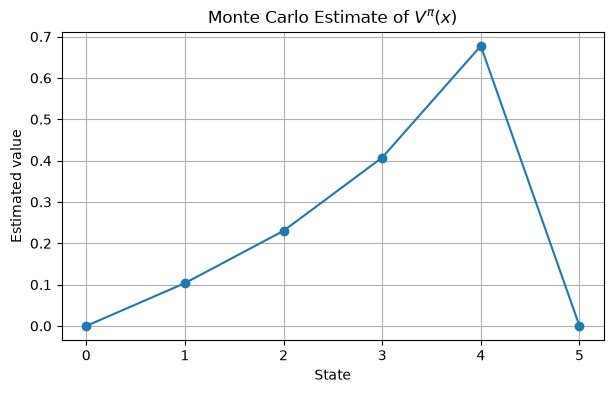

In [21]:
states = np.arange(N_STATES)

plt.figure(figsize=(7, 4))

plt.plot(
    states,
    V_mc,
    marker="o"
)

plt.xlabel("State")
plt.ylabel("Estimated value")
plt.title("Monte Carlo Estimate of $V^\\pi(x)$")
plt.grid()

plt.show()

## 9. Temporal Difference Learning

Monte Carlo estimates the value of a state using the complete observed return:

$$
G_t=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2r_{t+3}
+\cdots
$$

and updates:

$$
V(x_t)
\leftarrow
V(x_t)
+
\alpha
\left[
G_t-V(x_t)
\right].
$$

This requires waiting until enough future rewards have been observed.

Temporal Difference (TD) learning takes a different approach.

After observing only one transition:

$$
x_t
\rightarrow
u_t
\rightarrow
r_{t+1}
\rightarrow
x_{t+1},
$$

we already have two pieces of information:

- the immediate reward $r_{t+1}$,
- our current estimate of the next state's value $V(x_{t+1})$.

Therefore, we construct the TD target:

$$
\boxed{
r_{t+1}
+
\gamma V(x_{t+1})
}
$$

and update:

$$
\boxed{
V(x_t)
\leftarrow
V(x_t)+
\alpha
\left[
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t)
\right].
}
$$

Unlike Monte Carlo, TD does not need to wait until the episode terminates.

## 10. TD as a Sample-Based Bellman Update

The Bellman expectation equation tells us:

$$
V^\pi(x_t)=
\mathbb E_\pi
\left[
r_{t+1}
+
\gamma V^\pi(x_{t+1})
\mid x_t
\right].
$$

If the transition model is known, Dynamic Programming can explicitly compute
this expectation.

In model-free learning, we instead observe a sampled transition:

$$
(x_t,u_t,r_{t+1},x_{t+1}).
$$

This gives the sample-based target:

$$
y_t^{TD}=
r_{t+1}
+
\gamma V(x_{t+1}).
$$

The difference between this target and our current estimate is called the
Temporal Difference error:

$$
\boxed{
\delta_t=
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t)
}
$$

and the value update becomes:

$$
\boxed{
V(x_t)
\leftarrow
V(x_t)
+
\alpha\delta_t.
}
$$

TD learning can therefore be interpreted as a sample-based approximation of
the Bellman update.

## 11. Bootstrapping

Temporal Difference learning uses the current value estimate of the next state
to update the current state.

For example, suppose:

$$
V(x_t)=0.40
$$

and:

$$
V(x_{t+1})=0.70.
$$

After observing:

$$
r_{t+1}=0
$$

with:

$$
\gamma=0.9,
$$

the TD target is:

$$
y_t^{TD}=
0+0.9(0.70)=
0.63.
$$

The TD error is:

$$
\delta_t=
0.63-0.40=
0.23.
$$

With learning rate:

$$
\alpha=0.1,
$$

the update becomes:

$$
V(x_t)
\leftarrow
0.40+0.1(0.23)=
0.423.
$$

The value $V(x_{t+1})=0.70$ is itself only an estimate.

Therefore, TD is using one learned estimate to update another learned
estimate.

This is called:

$$
\boxed{\text{bootstrapping}}
$$

## 12. Monte Carlo vs Temporal Difference Learning

Both Monte Carlo and Temporal Difference methods learn value functions from
sampled experience without requiring the transition model.

Their main difference is the target used for learning.

### Monte Carlo

Monte Carlo waits for the sampled future return:

$$
\boxed{
y_t^{MC}=G_t
}
$$

where:

$$
G_t=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2r_{t+3}
+\cdots.
$$

The update is:

$$
V(x_t)
\leftarrow
V(x_t)
+
\alpha
\left[
G_t-V(x_t)
\right].
$$

Monte Carlo:

- uses sampled experience,
- does not bootstrap,
- generally waits for the future return to become available.

---

### Temporal Difference

TD uses:

$$
\boxed{
y_t^{TD}=
r_{t+1}
+
\gamma V(x_{t+1})
}
$$

and updates:

$$
V(x_t)
\leftarrow
V(x_t)+
\alpha
\left[
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t)
\right].
$$

TD:

- uses sampled experience,
- bootstraps from the current value estimate,
- can update after each transition.

Therefore:

$$
\boxed{
\text{MC: sample without bootstrapping}
}
$$

$$
\boxed{
\text{TD: sample + bootstrapping}
}
$$

## 13. TD(0) Policy Evaluation

We now estimate the value function of the same random policy using TD(0).

For every observed transition:

$$
(x_t,u_t,r_{t+1},x_{t+1}),
$$

we calculate:

$$
\delta_t=
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t)
$$

and immediately update:

$$
V(x_t)
\leftarrow
V(x_t)
+
\alpha\delta_t.
$$

The notation TD(0) indicates that the update uses the immediate reward and
the value estimate of the next state.

Unlike Monte Carlo, we do not need to store the complete episode before
updating the value function.

In [22]:
gamma = 0.9
alpha = 0.05

n_episodes = 10_000

V_td = np.zeros(N_STATES)

In [24]:
for _ in range(n_episodes):

    state = np.random.choice(
        [1, 2, 3, 4]
    )

    done = False

    while not done:

        action = random_policy(state)

        next_state, reward, done = environment_step(
            state,
            action
        )

        td_target = (
            reward
            + gamma * V_td[next_state]
        )

        td_error = (
            td_target
            - V_td[state]
        )

        V_td[state] += (
            alpha * td_error
        )

        state = next_state

## 14. Comparing Monte Carlo and TD Estimates

Monte Carlo and TD are different estimators of the same quantity:

$$
V^\pi(x).
$$

Monte Carlo estimates the value from complete sampled returns.

TD estimates the value using one-step rewards together with bootstrapped
value estimates.

If both methods receive sufficient experience under appropriate learning
conditions, their estimates should approach the value function of the same
policy.

The purpose of this comparison is therefore not to determine which algorithm
produces a different value function.

Both are attempting to estimate:

$$
\boxed{
V^\pi(x)
}
$$

but they learn it differently.

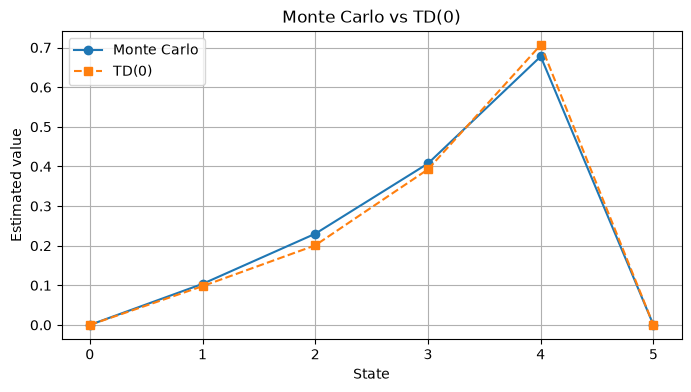

In [25]:
states = np.arange(N_STATES)

plt.figure(figsize=(8, 4))

plt.plot(
    states,
    V_mc,
    marker="o",
    label="Monte Carlo"
)

plt.plot(
    states,
    V_td,
    marker="s",
    linestyle="--",
    label="TD(0)"
)

plt.xlabel("State")
plt.ylabel("Estimated value")
plt.title("Monte Carlo vs TD(0)")
plt.legend()
plt.grid()

plt.show()

## 15. From Dynamic Programming to Temporal Difference Learning

Dynamic Programming, Monte Carlo, and Temporal Difference learning are closely
related methods for estimating value functions.

### Dynamic Programming

Uses the known transition model to compute an expected Bellman target:

$$
V^\pi(x)
\leftarrow
\mathbb E
\left[
r+\gamma V^\pi(x')
\right].
$$

Requires:

$$
T(x'|x,u).
$$

---

### Monte Carlo

Replaces the model-based expectation with a sampled complete return:

$$
V^\pi(x)
\leftarrow
G_t.
$$

Conceptually:

$$
\boxed{
\text{model expectation}
\rightarrow
\text{sampled return}
}
$$

No transition model is required and no bootstrapping is used.

---

### Temporal Difference

Uses a sampled transition but retains the recursive structure of the Bellman
equation:

$$
V(x_t)
\leftarrow
r_{t+1}
+
\gamma V(x_{t+1}).
$$

Conceptually:

$$
\boxed{
\text{sampled transition}
+
\text{Bellman bootstrapping}
}
$$

This gives the progression:

$$
\boxed{
\text{DP}
\rightarrow
\text{MC}
\rightarrow
\text{TD}
}
$$

where:

$$
\begin{array}{c|c|c}
\text{Method} & \text{Samples} & \text{Bootstrapping}\\
\hline
\text{DP} & \text{No} & \text{Yes}\\
\text{MC} & \text{Yes} & \text{No}\\
\text{TD} & \text{Yes} & \text{Yes}
\end{array}
$$

## 16. From State Values to Action Values

So far, we have considered the state-value function:

$$
V^\pi(x)=
\mathbb E_\pi
\left[
G_t\mid x_t=x
\right].
$$

This answers:

> How good is it to be in state $x$ while following policy $\pi$?

For control, however, we need to compare the actions available in a state.

This motivates the action-value function:

$$
\boxed{
Q^\pi(x,u)=
\mathbb E_\pi
\left[
G_t
\mid
x_t=x,\;u_t=u
\right].
}
$$

It answers:

> How good is it to take action $u$ in state $x$ and then continue following
> policy $\pi$?

For example, instead of knowing only:

$$
V^\pi(3),
$$

we can compare:

$$
Q^\pi(3,\text{LEFT})
$$

and

$$
Q^\pi(3,\text{RIGHT}).
$$

This makes action selection possible.

## 17. Why Action Values Are Useful for Model-Free Control

Suppose we know only the state-value function:

$$
V(x).
$$

To determine which action is best, we would need to predict what happens
after taking each action.

With a known model, this could be calculated using:

$$
Q^\pi(x,u)=
\sum_{x'}
T(x'|x,u)
\left[
R(x,u,x')
+
\gamma V^\pi(x')
\right].
$$

But in model-free reinforcement learning:

$$
T(x'|x,u)
$$

is unknown.

Instead, we can learn the action-value function directly from sampled
experience:

$$
(x_t,u_t,r_{t+1},x_{t+1}).
$$

Once $Q(x,u)$ is available, actions can be compared directly:

$$
u^*=
\arg\max_u Q(x,u).
$$

Therefore, action values provide a natural foundation for model-free control.

## 18. TD Learning for Action Values

The TD update for a state value was:

$$
V(x_t)
\leftarrow
V(x_t)+
\alpha
\left[
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t)
\right].
$$

For control, we instead want to learn:

$$
Q(x_t,u_t).
$$

A corresponding TD update has the form:

$$
Q(x_t,u_t)
\leftarrow
Q(x_t,u_t)+
\alpha
\left[
\text{target}-
Q(x_t,u_t)
\right].
$$

After observing:

$$
(x_t,u_t,r_{t+1},x_{t+1}),
$$

the target should contain:

$$
r_{t+1}
+
\gamma
\left(
\text{value of the next state-action decision}
\right).
$$

This creates an important question:

> Which action should be used to evaluate the next state?

Different answers to this question lead to different RL algorithms.

## 19. Two Ways to Construct the Next-Step Target

After observing:

$$
(x_t,u_t,r_{t+1},x_{t+1}),
$$

we need to determine how the next state contributes to the TD target.

There are two important possibilities.

### 1. Use the action actually selected by the policy

If the policy selects:

$$
u_{t+1},
$$

we can use:

$$
\boxed{
r_{t+1}
+
\gamma Q(x_{t+1},u_{t+1})
}
$$

as the TD target.

This leads to **SARSA**.

---

### 2. Use the currently best action

Instead of using the action actually selected, we can use:

$$
\max_u Q(x_{t+1},u).
$$

The target becomes:

$$
\boxed{
r_{t+1}
+
\gamma
\max_u Q(x_{t+1},u)
}
$$

This leads to **Q-learning**.

These two targets look very similar, but they correspond to an important
distinction between on-policy and off-policy learning.

## 20. Prediction vs Control

Reinforcement learning problems can be separated into two closely related
tasks.

### Prediction

Given a policy:

$$
\pi,
$$

estimate how good that policy is:

$$
V^\pi(x)
$$

or:

$$
Q^\pi(x,u).
$$

Monte Carlo and TD policy evaluation belong to this category.

---

### Control

The goal is no longer only to evaluate a fixed policy.

Instead, we want to improve the policy and eventually find:

$$
\pi^*.
$$

This requires repeatedly connecting:

$$
\text{value estimation}
$$

with:

$$
\text{policy improvement}.
$$

This is closely related to the Policy Iteration idea from Dynamic
Programming:

$$
\text{Policy Evaluation}
\rightarrow
\text{Policy Improvement}.
$$

The major difference is that in model-free RL, value estimates are learned
from sampled interaction rather than calculated from a known transition
model.

The next step is therefore:

$$
\boxed{
\text{TD Prediction}
\rightarrow
\text{TD Control}
}
$$

which leads to SARSA and Q-learning.

## 21. Reinforcement Learning Foundations — Summary

This notebook introduced the transition from Dynamic Programming to
model-free reinforcement learning.

### Dynamic Programming

With a known transition model:

$$
T(x'|x,u),
$$

Bellman expectations can be computed directly.

---

### Monte Carlo

When the model is unknown, values can instead be estimated from complete
sampled returns:

$$
G_t=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2r_{t+3}
+\cdots.
$$

The value estimate is learned from repeated experience:

$$
V^\pi(x)
\approx
\mathbb E[G_t|x_t=x].
$$

Monte Carlo uses:

$$
\boxed{\text{sampling without bootstrapping}}
$$

---

### Temporal Difference Learning

TD combines sampled transitions with Bellman-style bootstrapping:

$$
V(x_t)
\leftarrow
V(x_t)+
\alpha
\left[
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t)
\right].
$$

The TD error is:

$$
\delta_t=
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t).
$$

TD uses:

$$
\boxed{\text{sampling + bootstrapping}}
$$

and can learn during an episode.

---

### From Prediction to Control

State values answer:

$$
V^\pi(x)=
\text{How good is this state under policy }\pi?
$$

Action values answer:

$$
Q^\pi(x,u)=
\text{How good is this action in this state?}
$$

Learning $Q(x,u)$ allows actions to be compared without requiring an explicit
transition model.

This leads naturally to model-free control:

$$
\boxed{
\text{SARSA}
\quad\text{and}\quad
\text{Q-learning}
}
$$